## 🧭 Current Context
We're developing a:

**Synthetic mine simulation platform, focused on:**
* Blast pattern design (Trim, Ramp, Regular),
* Bench and phase logic,
* Scheduling and sequencing,
* Visualisation and interactivity.

**Using a Jupyter Notebook, with:**
* pandas, matplotlib, ipywidgets, scipy, and other libraries,
* Real-time visualisation,
* Heavy parameterisation and flexibility.

#### ✅ **Strengths of Staying in Jupyter (for now)**
| **Aspect**| **Advantage** |
|:----|:--------|
|🚀 Rapid Prototyping | Easy to tweak code, test changes, add diagnostics. |
|🧠 Explorability | Good-enough static and interactive plotting (with ipywidgets). |
|📸 Visuals |  Good-enough static and interactive plotting (with ipywidgets). |
|🧪 Research + Development | Ideal while your logic is still evolving (e.g. ramp trimming, slot strategy, final walls). |
|🔁 Refactor Friendly |  Fast to refactor sections, break into reusable functions, or inject new strategies. |


#### ❗️**Limitations we're Approaching**
| **Limitation**| **Risk** |
|:----|:--------|
|❌ UI Scalability | Dropdowns and matplotlib visuals won’t scale well to more complex user interactions (drag, select, zoom, edit). |
|❌ User-driven input | No clean way for users to “design” a blast or pick blocks interactively. |
|❌ Performance ceiling |  Large datasets, or multiple benches/phases, may hit UI lag or render bottlenecks. |
|❌ Distribution | Jupyter isn’t end-user friendly for sharing with non-coders or clients. |
	
	
#### 🔮 **When to Transition to an Application?**
Here’s a good rule of thumb:

🧱 When your domain logic stabilises, and you begin wanting to support interactive user input, reusable workflows, or non-technical users — it’s time to move to an application.

#### 🛠️ Transition Path

**Web Application with Backend + React Frontend**

*Ideal for scaling and user engagement.*

* **Frontend:** React + Tailwind + plot libraries (e.g., recharts, three.js, react-map-gl)
* **Backend:** FastAPI or Flask, running your core blast logic
* **Optional:** Jupyter kernel integration (for hybrid workflow)

|**Feature**|**Benefit**|
|:--|:--|
|🎯 Intuitive UI|Dropdowns, block selection, blast editing, zoom/pan|
|📡 API Layer|Connect to block models, auto-schedulers, NPV calculators|
|🔁 Multi-user|Could be used by engineers or planners|
|💾 Persistence|Save/load blast designs, tweak inputs, track versions|

#### 🔹**Next Steps:**
* ✅ Stay in Jupyter
* 🔄 Modularise your logic (functions for: trim check, ramp check, blast assignment, plot renderer)
* 🛠 Fix current issues (ramp/trim sequencing, slot-first strategy)

#### 🔸 Mid Term (Post-validation) — once you're confident in sequencing & logic:
* ⛓ Export logic to reusable Python modules
* 🚀 Begin building a FastAPI backend that serves:
	* Block models
	* Blast generation logic
	* Phase/period scheduling
* 🧪 Use tools like JupyterLab + Voila or Streamlit to bridge UI testing

#### 🔶 Long Term (App maturity):
* 🌐 Build a React UI that connects to your backend
* ✍️ Let users:
	* Upload/select pit shells or phase plans
	* Define slot direction and trim width
	* Edit pattern layouts
	* View Gantt/pit visuals
* 💡 Use your blast master as the base layer for export/visualisation/NAV

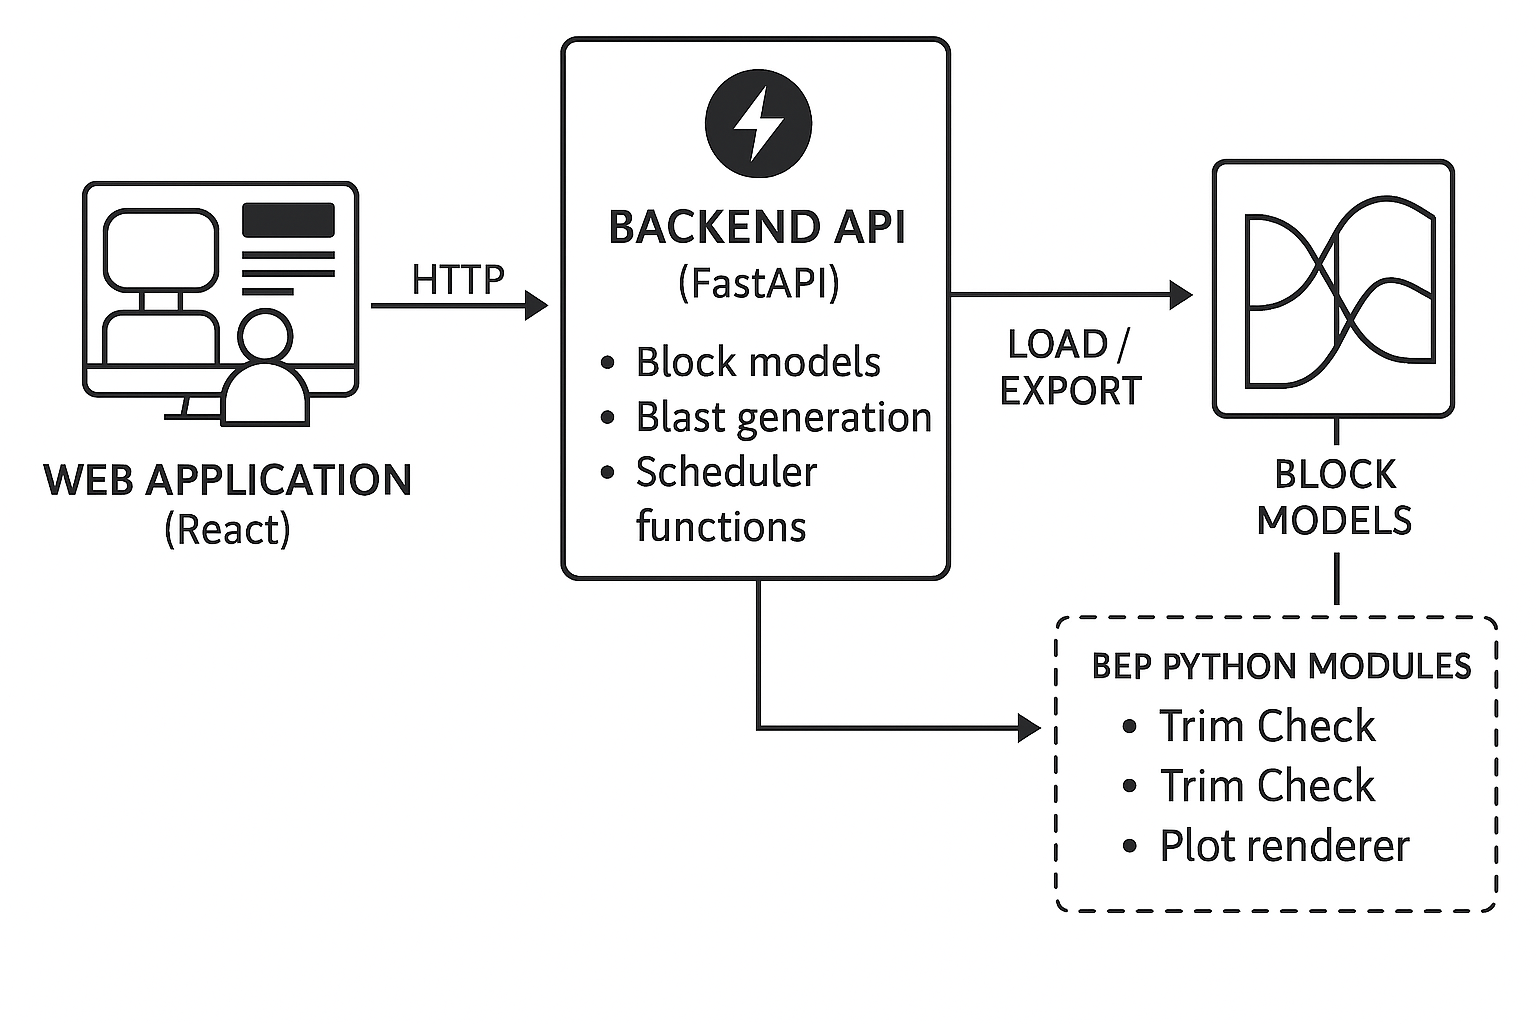

📊 Hybrid Mining Application Architecture Overview
This schematic diagram outlines a modular, hybrid web application architecture designed to support blast and excavation planning (BEP) for mining operations. It breaks down the system into three key tiers:

🖥️ 1. Web Application (Front-End UI)
Technology: Built in React.

Purpose: Interactive user interface for visualising benches, blast patterns, sequence numbers, and other spatially organized mining data.

Key Features:
* Bench selection dropdown
* Phase toggles
* Pattern color-coding
* Annotation overlays

🔄 2. Backend API (Logic & Orchestration)
Technology: Powered by FastAPI (Python).

Responsibilities:
* Serves block models and processed scheduling data
* Handles blast ID sequencing and pit development logic
* Interfaces between UI inputs and Python logic
* Returns data slices (e.g., selected bench, trimmed blasts)

🧠 3. BEP Python Modules (Mining Logic Layer)
Format: Core logic modularized into Python functions and utilities

Modules Shown:
* Blast Grouping: Determines blast_id based on spatial clustering
* Ramp Logic: Validates and tags ramp-shaped patterns based on size/shape
* Trim Check: Detects edge-bound or undersized patterns

Sequence Assignment: Applies pit development direction logic

🔗 Data Flow
Inputs like block models and configuration settings (bench height, truck width, etc.) feed into the BEP Python Modules.

Outputs (e.g., blast_master_table) are returned to the Web UI via the API, supporting live visualisation and interaction.

mine_simulator/
│
├── __init__.py
├── config.py                      # All user-defined parameters
├── io/
│   ├── __init__.py
│   ├── loader.py                  # Load block models (parquet, csv, etc.)
│   └── exporter.py                # Save scheduled blocks & summary
│
├── processing/
│   ├── __init__.py
│   ├── buffer_blocks.py          # Add top-bench waste buffers
│   └── value_calculator.py       # Calculate economic value
│
├── scheduling/
│   ├── __init__.py
│   ├── pit_shell.py              # Slope/berm + shell shape calc
│   ├── prestrip.py              # Prestrip logic + capex deduction
│   ├── binning.py               # Bin blocks by bench/pushback
│   ├── phase_assignment.py      # Assign phases spatially
│   └── period_scheduler.py      # Assign periods based on capacity
│
├── economics/
│   ├── __init__.py
│   ├── profit_filter.py         # Filter by profit threshold
│   └── npv_calculator.py        # NPV, payback period, cashflow
│
└── diagnostics/
    ├── __init__.py
    └── schedule_analyser.py     # Strip ratio spikes, vertical spread etc.
